# E9B - Does the longitude restriction map transfer to other solvers?

E9 established that low-rank matrix completion with a cross-validated rank reaches a lower aggregate
RMSE than STMAC on the 1999 network. That result stands. It raises a sharper question about what the
cellular-sheaf construction actually contributes.

The longitude sheaf is a claim about the physical structure of the data, not about our solver: local
solar time at a station leads the network mean by a fixed offset, so aligning every station into a
common solar-time frame should expose structure that any spatial method can use. If that claim is
correct, the same restriction map applied to a competing solver should improve that solver too.

This notebook tests it directly. Each baseline is run twice on identical masks: once in raw
coordinates, once with the rows shifted into local solar time, reconstructed there, and shifted back.
The alignment recipe is copied from `stmac_core.stmac` so the comparison isolates the restriction map
and nothing else: per-station linear interpolation, FFT shift by the longitude offset, mask rolled by
the rounded offset, reconstruction in solar time with observed values re-imposed, inverse FFT shift.

Two outcomes are informative. If alignment improves the baselines, the restriction map is a
contribution independent of the STMAC solver, and the method that outperforms us in aggregate becomes
evidence for our construction. If alignment does not improve them, the gain is specific to the
alternating-Tikhonov solver and the paper should say so.

In [1]:
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 10.5,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})


def _locate(name, marker):
    for c in (Path.cwd() / name, Path.cwd().parent / name,
              Path.cwd() / "notebooks" / name, Path.cwd().parent / "notebooks" / name):
        if (c / marker).exists():
            return c.resolve()
    raise FileNotFoundError(f"{name}/{marker} not found")


DATA = _locate("data", "multistation_1999_cleaned.parquet")
ROOT = DATA.parent
RES = ROOT / "results"; RES.mkdir(exist_ok=True)
for p in (Path.cwd().resolve(), ROOT, ROOT / "notebooks"):
    if (p / "stmac_core.py").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import stmac_core as sc
import stmac_scalable as ss
from stmac_core import fft_shift
from st_baselines import softimpute, grmf

N_SEEDS = 10
ALPHA_T, ALPHA_S, N_ITER = 10.0, 1.0, 4
KT_CLEAR, KT_CLOUDY = 0.85, 0.70


def atomic_csv(frame, path):
    tmp = Path(str(path) + ".tmp"); frame.to_csv(tmp, index=False); os.replace(tmp, path)


print("DATA   :", DATA)
print("RESULTS:", RES)

DATA   : /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/data
RESULTS: /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/results


## 1. Network, solar-time offsets, and sky classification

Identical to E9 so the two notebooks are directly comparable: same parquet, column order aligned to
`stations.json`, evaluation window 08:00 to 16:00, and clear-sky index from a Haurwitz curve
aggregated per station and per day.

In [2]:
multi = pd.read_parquet(DATA / "multistation_1999_cleaned.parquet")
STATIONS = json.load(open(DATA / "stations.json"))
CODES = list(STATIONS.keys())
multi = multi[CODES]

LAT = np.array([STATIONS[c]["lat"] for c in CODES], float)
LON = np.array([STATIONS[c]["lon"] for c in CODES], float)
U_ALL = multi.to_numpy().T.astype(float)
N, T = U_ALL.shape

DELTA = (LON - LON.mean()) / 15 * 60 / 5
L_G = np.load(DATA / "graph_L.npy")
L_TIME = sc.build_temporal_smoothness(T)
IDX = multi.index
DAYTIME = (IDX.hour.values >= 8) & (IDX.hour.values <= 16)

import sky_tools as sk

UTC_OFFSET, _est = sk.detect_utc_offset(IDX, U_ALL, LON)
COSZ, CS = sk.clear_sky_field(IDX, LAT, LON, UTC_OFFSET)
KT = sk.daily_clear_sky_index(IDX, U_ALL, CS, DAYTIME)
CLEAR, CLOUDY = sk.sky_masks(KT, KT_CLEAR, KT_CLOUDY)
_kt, _lo, _hi = sk.instantaneous_kt(U_ALL, CS, np.ones_like(U_ALL, bool) & DAYTIME[None, :])

print(f"detected clock offset of this record: UTC{UTC_OFFSET:+.1f} "
      f"(per-station estimates {_est.min():+.2f} to {_est.max():+.2f} h)")
print(f"instantaneous clear-sky index: mean {_kt.mean():.3f}, sd {_kt.std():.3f}, "
      f"pinned at the bounds {_lo*100:.1f}% low and {_hi*100:.1f}% high")
print(f"stations {N} | timestamps {T:,} | daytime cells {DAYTIME.sum():,}")
print(f"solar-time offsets, samples: min {DELTA.min():+.1f} max {DELTA.max():+.1f} "
      f"(= {DELTA.min()*5:+.0f} to {DELTA.max()*5:+.0f} minutes)")
print(f"clear-day cells {np.nanmean(CLEAR[:, DAYTIME])*100:.1f}%, "
      f"cloudy-day cells {np.nanmean(CLOUDY[:, DAYTIME])*100:.1f}%, "
      f"intermediate {100 - np.nanmean(CLEAR[:, DAYTIME])*100 - np.nanmean(CLOUDY[:, DAYTIME])*100:.1f}%")

detected clock offset of this record: UTC+3.0 (per-station estimates +2.82 to +3.19 h)
instantaneous clear-sky index: mean 0.887, sd 0.250, pinned at the bounds 0.0% low and 2.5% high
stations 11 | timestamps 101,805 | daytime cells 38,730
solar-time offsets, samples: min -3.7 max +4.5 (= -19 to +23 minutes)
clear-day cells 74.5%, cloudy-day cells 11.5%, intermediate 14.0%


## 2. The alignment wrapper

`with_solar_alignment` applies the longitude restriction map around an arbitrary reconstruction
function. The steps mirror `stmac_core.stmac` exactly, so the only difference between an aligned and
an unaligned run is the change of coordinates.

In [3]:
def _interp_init(Y, mask):
    """Per-station linear interpolation over observed samples, as in stmac_core."""
    Nn, Tt = Y.shape
    out = np.zeros_like(Y)
    for i in range(Nn):
        obs = np.where(mask[i])[0]
        if len(obs) < 2:
            out[i] = Y[mask].mean() if mask.any() else 0.0
            continue
        out[i] = np.interp(np.arange(Tt), obs, Y[i, obs])
    return out


def with_solar_alignment(fn, Y, mask, delta):
    """Run `fn(Y_solar, mask_solar)` in local-solar-time coordinates and shift back.

    fn    : callable taking (data, mask) and returning a full reconstruction.
    delta : per-station offset in samples, positive means the station leads the mean.
    """
    Nn, Tt = Y.shape
    U_init = _interp_init(Y, mask)
    Y_solar = np.array([fft_shift(U_init[i], +delta[i]) for i in range(Nn)])
    mask_solar = np.zeros_like(mask)
    for i in range(Nn):
        mask_solar[i] = np.roll(mask[i], int(round(delta[i])))
    X_solar = fn(Y_solar, mask_solar)
    return np.array([fft_shift(X_solar[i], -delta[i]) for i in range(Nn)])


# sanity check: wrapping the STMAC spatial-temporal solver with the wrapper and feeding it a
# trivial sheaf must reproduce the built-in longitude sheaf to within FFT round-off
_m, _ = sc.build_block_mask(N, T, 864, 0.10, seed=0)
_ev = (~_m) & DAYTIME[None, :]
_Y = np.where(_m, U_ALL, 0.0)
_builtin = ss.stmac_scalable(_Y, _m, L_G, L_TIME, DELTA, N_ITER, ALPHA_T, ALPHA_S)
_wrapped = with_solar_alignment(
    lambda d, m: ss.stmac_scalable(d, m, L_G, L_TIME, None, N_ITER, ALPHA_T, ALPHA_S),
    _Y, _m, DELTA)
print(f"wrapper check on STMAC: built-in {sc.rmse(U_ALL, _builtin, _ev):.3f} W/m2, "
      f"wrapped {sc.rmse(U_ALL, _wrapped, _ev):.3f} W/m2")

wrapper check on STMAC: built-in 202.083 W/m2, wrapped 202.083 W/m2


## 3. Baseline configurations

The configurations selected in E9 are reused unchanged. `E9_selected_configs.csv` is read if present;
otherwise the values reported by that notebook are used as defaults. Aligned and unaligned runs share
the same configuration, so no method gains an advantage from re-tuning inside the new coordinates.

In [4]:
SEL_PATH = RES / "E9_selected_configs.csv"
DEFAULT_SI = dict(rank=1, lam=1000.0)
DEFAULT_GR = dict(rank=1, lam_s=0.1, lam_t=1000.0)

SI_CFG, GR_CFG = {}, {}
if SEL_PATH.exists():
    SEL = pd.read_csv(SEL_PATH); SEL["config"] = SEL["config"].apply(json.loads)
    for bl, lab in sc.BLOCK_SPECS:
        s = SEL[(SEL.method == "softimpute") & (SEL.criterion == "cv") & (SEL.block_len == bl)]
        g = SEL[(SEL.method == "grmf") & (SEL.criterion == "oracle") & (SEL.block_len == bl)]
        SI_CFG[bl] = dict(s.iloc[0]["config"]) if len(s) else dict(DEFAULT_SI)
        GR_CFG[bl] = dict(g.iloc[0]["config"]) if len(g) else dict(DEFAULT_GR)
    print("configurations read from E9_selected_configs.csv")
else:
    for bl, lab in sc.BLOCK_SPECS:
        SI_CFG[bl] = dict(DEFAULT_SI); GR_CFG[bl] = dict(DEFAULT_GR)
    print("E9_selected_configs.csv not found; using the values reported by E9")

for bl, lab in sc.BLOCK_SPECS:
    print(f"  {lab:>7s} low-rank {SI_CFG[bl]} | GRMF {GR_CFG[bl]}")

configurations read from E9_selected_configs.csv
   30 min low-rank {'rank': 1, 'lam': 1000.0} | GRMF {'rank': 1, 'lam_s': 0.1, 'lam_t': 1000.0}
      2 h low-rank {'rank': 1, 'lam': 1000.0} | GRMF {'rank': 1, 'lam_s': 0.1, 'lam_t': 1000.0}
      6 h low-rank {'rank': 1, 'lam': 1000.0} | GRMF {'rank': 1, 'lam_s': 10.0, 'lam_t': 1000.0}
     12 h low-rank {'rank': 1, 'lam': 1000.0} | GRMF {'rank': 1, 'lam_s': 10.0, 'lam_t': 1000.0}
    1 day low-rank {'rank': 1, 'lam': 1000.0} | GRMF {'rank': 1, 'lam_s': 0.1, 'lam_t': 1000.0}
    3 day low-rank {'rank': 1, 'lam': 1000.0} | GRMF {'rank': 1, 'lam_s': 0.1, 'lam_t': 1000.0}
    7 day low-rank {'rank': 1, 'lam': 1000.0} | GRMF {'rank': 1, 'lam_s': 10.0, 'lam_t': 1000.0}


## 4. Sweep

Six conditions on identical masks, seed by seed. The two STMAC rows are references; the four baseline
rows are the test. Rows are written with atomic replacement so an interrupted run resumes.

In [5]:
NAMES = ["stmac_trivial", "stmac_longitude",
         "lowrank_raw", "lowrank_aligned", "grmf_raw", "grmf_aligned"]
LABEL = {"stmac_trivial": "STMAC trivial sheaf", "stmac_longitude": "STMAC longitude sheaf",
         "lowrank_raw": "Low-rank, raw time", "lowrank_aligned": "Low-rank, solar time",
         "grmf_raw": "Graph-reg. MF, raw time", "grmf_aligned": "Graph-reg. MF, solar time"}

SWEEP = RES / "E9B_raw.csv"
rows = pd.read_csv(SWEEP).to_dict("records") if SWEEP.exists() else []
done = {(r["seed"], r["block_len"]) for r in rows}
t_start = time.time()

for seed in range(N_SEEDS):
    for block_len, label in sc.BLOCK_SPECS:
        if (seed, block_len) in done:
            continue
        mask, n_blk = sc.build_block_mask(N, T, block_len, 0.10, seed=seed)
        ev = (~mask) & DAYTIME[None, :]
        ev_clear, ev_cloudy = ev & CLEAR, ev & CLOUDY
        Y = np.where(mask, U_ALL, 0.0)
        si, gr = SI_CFG[block_len], GR_CFG[block_len]

        runs = {
            "stmac_trivial":   lambda: ss.stmac_scalable(Y, mask, L_G, L_TIME, None,
                                                         N_ITER, ALPHA_T, ALPHA_S),
            "stmac_longitude": lambda: ss.stmac_scalable(Y, mask, L_G, L_TIME, DELTA,
                                                         N_ITER, ALPHA_T, ALPHA_S),
            "lowrank_raw":     lambda: softimpute(Y, mask, **si),
            "lowrank_aligned": lambda: with_solar_alignment(
                lambda d, m: softimpute(d, m, **si), Y, mask, DELTA),
            "grmf_raw":        lambda: grmf(Y, mask, L_G, L_TIME, **gr),
            "grmf_aligned":    lambda: with_solar_alignment(
                lambda d, m: grmf(d, m, L_G, L_TIME, **gr), Y, mask, DELTA),
        }

        rec = {"seed": seed, "block_len": block_len, "block_label": label, "n_blocks": n_blk,
               "n_eval": int(ev.sum()), "n_clear": int(ev_clear.sum()),
               "n_cloudy": int(ev_cloudy.sum())}
        for name in NAMES:
            t0 = time.time()
            X = runs[name]()
            rec["rmse_" + name] = sc.rmse(U_ALL, X, ev)
            rec["clear_" + name] = sc.rmse(U_ALL, X, ev_clear)
            rec["cloudy_" + name] = sc.rmse(U_ALL, X, ev_cloudy)
            rec["sec_" + name] = time.time() - t0
        rows.append(rec)
        atomic_csv(pd.DataFrame(rows), SWEEP)
        print(f"seed={seed:2d} {label:>7s} | LR raw={rec['rmse_lowrank_raw']:6.1f} "
              f"aligned={rec['rmse_lowrank_aligned']:6.1f} | GRMF raw={rec['rmse_grmf_raw']:6.1f} "
              f"aligned={rec['rmse_grmf_aligned']:6.1f} | STMAC lon={rec['rmse_stmac_longitude']:6.1f}"
              f" | {(time.time()-t_start)/60:5.1f} min", flush=True)

E9B = pd.DataFrame(rows)
print(f"\ndone: {len(E9B)} rows in {(time.time()-t_start)/60:.1f} min")

seed= 0  30 min | LR raw= 191.1 aligned= 189.1 | GRMF raw= 189.4 aligned= 187.4 | STMAC lon= 196.1 |   0.3 min
seed= 0     2 h | LR raw= 188.7 aligned= 187.0 | GRMF raw= 188.0 aligned= 186.4 | STMAC lon= 190.5 |   0.7 min
seed= 0     6 h | LR raw= 185.8 aligned= 184.8 | GRMF raw= 185.4 aligned= 184.4 | STMAC lon= 186.6 |   1.0 min
seed= 0    12 h | LR raw= 188.4 aligned= 186.9 | GRMF raw= 188.1 aligned= 186.5 | STMAC lon= 187.7 |   1.5 min
seed= 0   1 day | LR raw= 200.8 aligned= 198.8 | GRMF raw= 200.5 aligned= 198.5 | STMAC lon= 199.7 |   1.7 min
seed= 0   3 day | LR raw= 192.0 aligned= 188.3 | GRMF raw= 191.5 aligned= 187.8 | STMAC lon= 202.1 |   2.0 min
seed= 0   7 day | LR raw= 179.9 aligned= 178.9 | GRMF raw= 179.8 aligned= 178.7 | STMAC lon= 182.8 |   2.2 min
seed= 1  30 min | LR raw= 192.4 aligned= 189.4 | GRMF raw= 190.5 aligned= 187.6 | STMAC lon= 197.3 |   2.4 min
seed= 1     2 h | LR raw= 194.7 aligned= 192.3 | GRMF raw= 194.1 aligned= 191.7 | STMAC lon= 196.8 |   2.7 min
s

## 5. Paired tests

Three alignment contrasts are tested: low-rank raw against low-rank aligned, GRMF raw against GRMF
aligned, and STMAC trivial against STMAC longitude. Each contrast is a family of seven block lengths
with Holm correction inside the family, tested on the aggregate and on cloudy-day cells.

In [6]:
def ci95(x):
    x = np.asarray(x, float); m = x.mean()
    h = x.std(ddof=1) / np.sqrt(len(x)) * stats.t.ppf(0.975, len(x) - 1)
    return m, m - h, m + h


def holm(p):
    p = np.asarray(p, float); order = np.argsort(p); k = len(p)
    adj = np.empty(k); run = 0.0
    for i, idx in enumerate(order):
        run = max(run, (k - i) * p[idx]); adj[idx] = min(run, 1.0)
    return adj


CONTRASTS = [("lowrank", "lowrank_raw", "lowrank_aligned"),
             ("grmf", "grmf_raw", "grmf_aligned"),
             ("stmac", "stmac_trivial", "stmac_longitude")]

frames = {}
for tag, pre in [("all", "rmse_"), ("cloudy", "cloudy_"), ("clear", "clear_")]:
    summ = []
    for bl, lab in sc.BLOCK_SPECS:
        g = E9B[E9B.block_len == bl]
        row = {"block_len": bl, "label": lab, "n": len(g)}
        for n in NAMES:
            mu, lo, hi = ci95(g[pre + n])
            row[n], row[n + "_lo"], row[n + "_hi"] = mu, lo, hi
        summ.append(row)
    frames[tag] = pd.DataFrame(summ)
    atomic_csv(frames[tag], RES / f"E9B_summary_{tag}.csv")

tests = []
for tag, pre in [("all", "rmse_"), ("cloudy", "cloudy_")]:
    for name, raw, aligned in CONTRASTS:
        hold, praw = [], []
        for bl, lab in sc.BLOCK_SPECS:
            g = E9B[E9B.block_len == bl]
            d = g[pre + raw].to_numpy(float) - g[pre + aligned].to_numpy(float)
            try:
                p = stats.wilcoxon(g[pre + raw], g[pre + aligned]).pvalue
            except ValueError:
                p = 1.0
            mu, lo, hi = ci95(d)
            hold.append({"subset": tag, "contrast": name, "label": lab, "gain": mu,
                         "ci_lo": lo, "ci_hi": hi, "wins_aligned": int((d > 0).sum()),
                         "n": len(d)})
            praw.append(p)
        for r_, p_, ph in zip(hold, praw, holm(praw)):
            r_["p_wilcoxon"], r_["p_holm"] = p_, ph
        tests += hold
TST = pd.DataFrame(tests)
atomic_csv(TST, RES / "E9B_alignment_tests.csv")

pooled = []
for tag, pre in [("all", "rmse_"), ("cloudy", "cloudy_")]:
    for name, raw, aligned in CONTRASTS:
        d = (E9B[pre + raw] - E9B[pre + aligned]).to_numpy(float)
        try:
            p = stats.wilcoxon(E9B[pre + raw], E9B[pre + aligned]).pvalue
        except ValueError:
            p = 1.0
        mu, lo, hi = ci95(d)
        pooled.append({"subset": tag, "contrast": name, "gain": mu, "ci_lo": lo, "ci_hi": hi,
                       "wins_aligned": int((d > 0).sum()), "n": len(d), "p_wilcoxon": p})
POOL = pd.DataFrame(pooled)
atomic_csv(POOL, RES / "E9B_alignment_pooled.csv")

print("AGGREGATE")
print(frames["all"][["label"] + NAMES].to_string(index=False, float_format=lambda v: f"{v:8.1f}"))
print("\nPOOLED ACROSS ALL SEEDS AND BLOCK LENGTHS (positive gain means alignment helps)")
print(POOL.to_string(index=False, float_format=lambda v: f"{v:9.3g}"))

AGGREGATE
 label  stmac_trivial  stmac_longitude  lowrank_raw  lowrank_aligned  grmf_raw  grmf_aligned
30 min          197.3            196.0        191.5            188.9     189.7         187.2
   2 h          197.4            196.7        191.5            189.7     190.9         189.1
   6 h          193.2            192.3        189.8            187.6     189.4         187.3
  12 h          195.5            195.1        190.8            189.2     190.4         188.8
 1 day          194.1            193.3        190.6            188.6     190.4         188.3
 3 day          198.5            197.9        191.1            189.1     190.8         188.8
 7 day          194.2            193.9        191.4            189.6     191.1         189.3

POOLED ACROSS ALL SEEDS AND BLOCK LENGTHS (positive gain means alignment helps)
subset contrast      gain     ci_lo     ci_hi  wins_aligned  n  p_wilcoxon
   all  lowrank         2      1.81      2.18            70 70    3.56e-13
   all     grmf

## 6. Figure

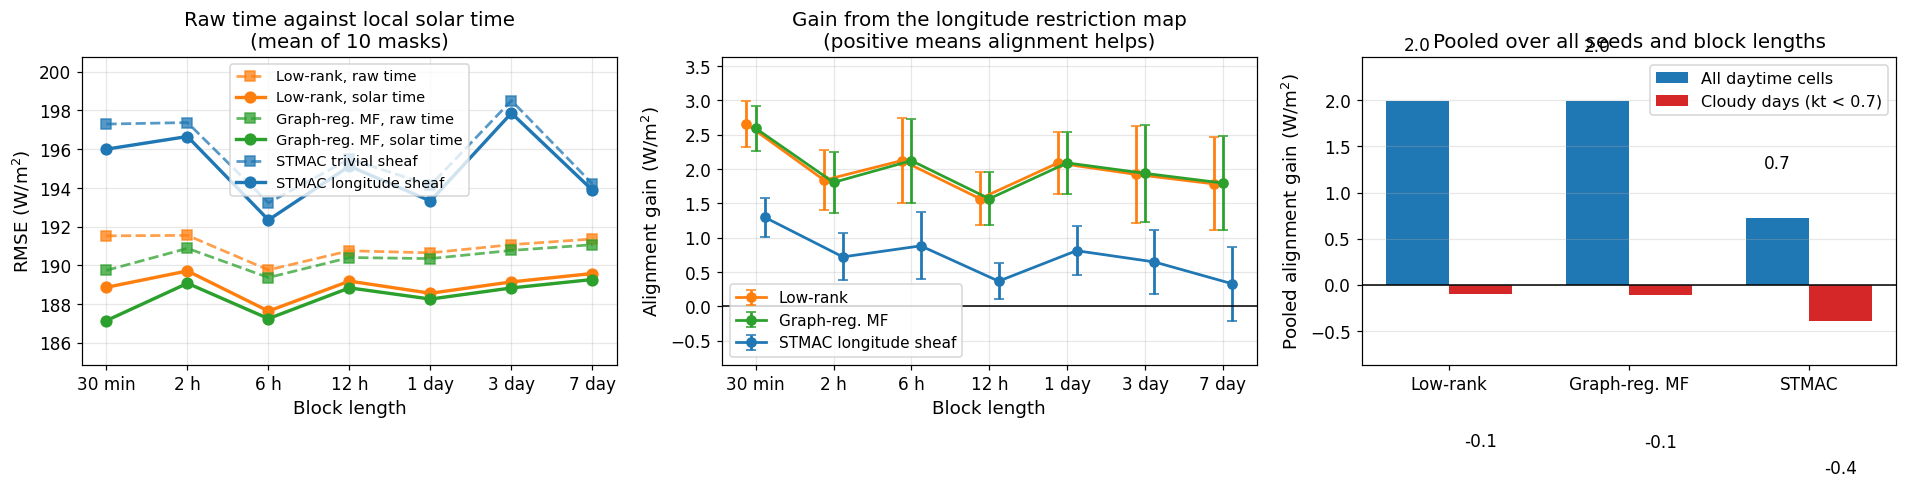

In [7]:
x = np.arange(len(sc.BLOCK_SPECS))
labels = [l for _, l in sc.BLOCK_SPECS]
fig, ax = plt.subplots(1, 3, figsize=(17.5, 4.9))

S_ = frames["all"]
pairs = [("lowrank_raw", "lowrank_aligned", "C1"), ("grmf_raw", "grmf_aligned", "C2"),
         ("stmac_trivial", "stmac_longitude", "C0")]
for raw, aligned, c in pairs:
    ax[0].plot(x, S_[raw], "--", color=c, marker="s", lw=1.8, ms=6, alpha=0.75, label=LABEL[raw])
    ax[0].plot(x, S_[aligned], "-", color=c, marker="o", lw=2.2, ms=7, label=LABEL[aligned])
ax[0].set_xticks(x); ax[0].set_xticklabels(labels)
ax[0].set_xlabel("Block length"); ax[0].set_ylabel(r"RMSE (W/m$^2$)")
ax[0].set_title(f"Raw time against local solar time\n(mean of {N_SEEDS} masks)")
ax[0].legend(frameon=True, fontsize=9.5); ax[0].grid(alpha=0.3); ax[0].margins(y=0.20)

for k, (name, raw, aligned) in enumerate(CONTRASTS):
    sub = TST[(TST.subset == "all") & (TST.contrast == name)]
    ax[1].errorbar(x + (k - 1) * 0.12, sub.gain,
                   yerr=[sub.gain - sub.ci_lo, sub.ci_hi - sub.gain],
                   fmt="o-", lw=1.8, ms=6, capsize=3,
                   color=["C1", "C2", "C0"][k], label=LABEL[aligned].split(",")[0])
ax[1].axhline(0, color="k", lw=1)
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_xlabel("Block length"); ax[1].set_ylabel(r"Alignment gain (W/m$^2$)")
ax[1].set_title("Gain from the longitude restriction map\n(positive means alignment helps)")
ax[1].legend(frameon=True, fontsize=10); ax[1].grid(alpha=0.3); ax[1].margins(y=0.20)

w = 0.35
xn = np.arange(len(CONTRASTS))
gain_all = [POOL[(POOL.subset == "all") & (POOL.contrast == c)].gain.iloc[0] for c, _, _ in CONTRASTS]
gain_cld = [POOL[(POOL.subset == "cloudy") & (POOL.contrast == c)].gain.iloc[0] for c, _, _ in CONTRASTS]
b1 = ax[2].bar(xn - w / 2, gain_all, w, color="C0", label="All daytime cells")
b2 = ax[2].bar(xn + w / 2, gain_cld, w, color="C3", label=f"Cloudy days (kt < {KT_CLOUDY})")
for bars in (b1, b2):
    for b in bars:
        off = 0.5 if b.get_height() >= 0 else -1.5
        ax[2].text(b.get_x() + b.get_width() / 2, b.get_height() + off, f"{b.get_height():.1f}",
                   ha="center", va="bottom" if b.get_height() >= 0 else "top", fontsize=11)
ax[2].axhline(0, color="k", lw=1)
ax[2].set_xticks(xn); ax[2].set_xticklabels(["Low-rank", "Graph-reg. MF", "STMAC"])
ax[2].set_ylabel(r"Pooled alignment gain (W/m$^2$)")
ax[2].set_title("Pooled over all seeds and block lengths")
ax[2].legend(frameon=True); ax[2].grid(alpha=0.3, axis="y"); ax[2].margins(y=0.20)

fig.tight_layout()
fig.savefig(RES / "E9B_alignment_transfer.png")
plt.show()

## 7. Automatic readout

In [8]:
SA = pd.read_csv(RES / "E9B_summary_all.csv")
SC_ = pd.read_csv(RES / "E9B_summary_cloudy.csv")
TT = pd.read_csv(RES / "E9B_alignment_tests.csv")
PL = pd.read_csv(RES / "E9B_alignment_pooled.csv")

n_ev = E9B.n_eval.sum()
pc_clear = E9B.n_clear.sum() / n_ev * 100
pc_cloudy = E9B.n_cloudy.sum() / n_ev * 100

print("SUMMARY")
print("=" * 84)
print("1. Evaluation cells")
print(f"   clear days {pc_clear:.1f}%, cloudy days {pc_cloudy:.1f}%, "
      f"intermediate {100 - pc_clear - pc_cloudy:.1f}%")
print(f"   solar-time offsets span {DELTA.min()*5:+.0f} to {DELTA.max()*5:+.0f} minutes "
      f"across the network")

print("\n2. Per-block alignment gain, aggregate")
for name, raw, aligned in CONTRASTS:
    s = TT[(TT.subset == "all") & (TT.contrast == name)]
    sig = int((s.p_holm < 0.05).sum())
    print(f"   {name:8s}: aligned wins {int((s.gain > 0).sum())}/{len(s)} block lengths "
          f"(significant {sig}), gain {s.gain.min():+.2f} to {s.gain.max():+.2f} W/m2")

print("\n3. Per-block alignment gain, cloudy days")
for name, raw, aligned in CONTRASTS:
    s = TT[(TT.subset == "cloudy") & (TT.contrast == name)]
    sig = int((s.p_holm < 0.05).sum())
    print(f"   {name:8s}: aligned wins {int((s.gain > 0).sum())}/{len(s)} block lengths "
          f"(significant {sig}), gain {s.gain.min():+.2f} to {s.gain.max():+.2f} W/m2")

print("\n4. Pooled over all seeds and block lengths")
for _, r in PL.iterrows():
    verdict = "helps" if r.gain > 0 and r.p_wilcoxon < 0.05 else (
        "hurts" if r.gain < 0 and r.p_wilcoxon < 0.05 else "no detectable effect")
    print(f"   {r.contrast:8s} {r.subset:6s}: gain {r.gain:+6.2f} W/m2 "
          f"[{r.ci_lo:+.2f}, {r.ci_hi:+.2f}], aligned wins {int(r.wins_aligned)}/{int(r.n)}, "
          f"p = {r.p_wilcoxon:.2e} -> {verdict}")

print("\n5. Where each method lands")
for n in NAMES:
    print(f"   {LABEL[n]:28s} aggregate {SA[n].mean():6.1f} W/m2 | "
          f"cloudy {SC_[n].mean():6.1f} W/m2 | {E9B['sec_' + n].mean():5.1f} s per run")

print("\n6. Final sentences for the manuscript")
lr = PL[(PL.subset == "all") & (PL.contrast == "lowrank")].iloc[0]
st = PL[(PL.subset == "all") & (PL.contrast == "stmac")].iloc[0]
gr = PL[(PL.subset == "all") & (PL.contrast == "grmf")].iloc[0]
if lr.gain > 0 and lr.p_wilcoxon < 0.05:
    print("   \"The longitude restriction map was applied to the competing solvers by reconstructing")
    print("    in local-solar-time coordinates and transforming back. Low-rank matrix completion")
    print(f"    improves by {lr.gain:.2f} W/m2 [{lr.ci_lo:.2f}, {lr.ci_hi:.2f}] under the same alignment (paired Wilcoxon over")
    print(f"    {int(lr.n)} mask realisations, p = {lr.p_wilcoxon:.1e}), and graph-regularised matrix factorisation by")
    print(f"    {gr.gain:.2f} W/m2. The restriction map therefore carries information that is not specific to the")
    print(f"    alternating-Tikhonov solver, where the same change of coordinates is worth {st.gain:.2f} W/m2.\"")
else:
    print("   \"The longitude restriction map was applied to the competing solvers by reconstructing")
    print("    in local-solar-time coordinates and transforming back. The change of coordinates is")
    print(f"    worth {st.gain:+.2f} W/m2 inside the alternating-Tikhonov solver but {lr.gain:+.2f} W/m2 for low-rank")
    print(f"    completion (p = {lr.p_wilcoxon:.2f}) and {gr.gain:+.2f} W/m2 for graph-regularised matrix factorisation.")
    print("    The benefit of the restriction map is therefore specific to the solver in which the")
    print("    sheaf Laplacian appears, and is reported as such.\"")

SUMMARY
1. Evaluation cells
   clear days 74.5%, cloudy days 11.7%, intermediate 13.9%
   solar-time offsets span -19 to +23 minutes across the network

2. Per-block alignment gain, aggregate
   lowrank : aligned wins 7/7 block lengths (significant 7), gain +1.57 to +2.66 W/m2
   grmf    : aligned wins 7/7 block lengths (significant 7), gain +1.57 to +2.59 W/m2
   stmac   : aligned wins 7/7 block lengths (significant 6), gain +0.33 to +1.30 W/m2

3. Per-block alignment gain, cloudy days
   lowrank : aligned wins 3/7 block lengths (significant 1), gain -0.97 to +1.38 W/m2
   grmf    : aligned wins 3/7 block lengths (significant 1), gain -0.96 to +1.30 W/m2
   stmac   : aligned wins 1/7 block lengths (significant 1), gain -1.36 to +0.68 W/m2

4. Pooled over all seeds and block lengths
   lowrank  all   : gain  +2.00 W/m2 [+1.81, +2.18], aligned wins 70/70, p = 3.56e-13 -> helps
   grmf     all   : gain  +1.99 W/m2 [+1.80, +2.17], aligned wins 70/70, p = 3.56e-13 -> helps
   stmac    all 